# PaliGemma 2 — Resolution vs. Turkish OCR

A small exploratory experiment for the Freya Research Fellows program.

This notebook asks whether higher input resolution helps PaliGemma 2 read Turkish text in real-world images. It is inspired by the model-size and resolution analysis in [Steiner et al. (2024)](https://arxiv.org/abs/2412.03555).

| Component | Choice |
|---|---|
| Models | PaliGemma 2 3B Mix 224 and PaliGemma 2 3B Mix 448 |
| Task | Turkish OCR, inference only |
| Evaluation | Qualitative inspection and Character Error Rate (CER) |

Both checkpoints were evaluated on 10 Turkish real-world OCR images in Google Colab using `OCR_PROMPT = "ocr"`. The saved outputs below are from the completed experiment.

## 1. Research Question

**Does increasing PaliGemma 2's input resolution from 224×224 to 448×448 improve its ability to read Turkish text in real-world images?**

**Hypothesis:** preserving more fine visual detail may reduce recognition errors, especially for small, dense, distant, or otherwise difficult text. This is an expectation to test, not an observed result.

10 manually selected images provide a small exploratory comparison, not a benchmark. We do not claim statistical significance or treat this experiment as proof or disproof of the paper.

## 2. Why Resolution Might Matter

PaliGemma 2 combines a SigLIP-So400m vision encoder with a Gemma 2 language decoder. Image features become visual tokens, which are processed together with the text instruction. With 14×14-pixel patches:

$$224/14 = 16,\qquad 16\times16 = 256$$
$$448/14 = 32,\qquad 32\times32 = 1024$$

| Resolution | Patch Grid | Visual Tokens |
|---|---|---|
| 224×224 | 16×16 | 256 |
| 448×448 | 32×32 | 1024 |

The 448 checkpoint uses four times as many visual tokens. This can preserve finer details but increases computation and memory use; more tokens do not guarantee better OCR. The paper reports resolution-sensitive trends for text, document, screen, and chart understanding after task-specific transfer ([Section 4.1](https://arxiv.org/html/2412.03555v1#S4.SS1)).

## 3. Experimental Design

| Role | Variable |
|---|---|
| Independent variable | Resolution-specific checkpoint: 224 or 448 |
| Controlled variables | Original images, prompt, model family, approximately 3B parameters, numerical precision, generation settings, normalization, evaluation |
| Dependent variable | Per-image CER and its mean across images |

Qualitative inspection complements CER because errors with similar character counts may have different practical consequences.

Only the resolution/checkpoint choice changes in our inference setup. These are separately trained checkpoint weights, so this is not a pure resizing intervention on identical weights. The paper studies task-specific fine-tuning; our use of ready-to-run Mix checkpoints tests a related trend in an inference-only setting.

The setup below pins Transformers to a documented release supporting PaliGemma 2 and keeps Colab's existing PyTorch installation. Select a GPU runtime before running. If dependencies were already imported, restart the session after installation.

In [1]:
from pathlib import Path

REPO_DIR = Path("/content/yz50")

if not REPO_DIR.exists():
    !git clone --filter=blob:none --no-checkout https://github.com/EdizArkin/yz50 /content/yz50
    !git -C /content/yz50 sparse-checkout init --cone
    !git -C /content/yz50 sparse-checkout set researchFellow/paligemma2
    !git -C /content/yz50 checkout
else:
    !git -C /content/yz50 pull

Cloning into '/content/yz50'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 139 (delta 60), reused 102 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 23.37 KiB | 11.68 MiB/s, done.
Resolving deltas: 100% (60/60), done.
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 0), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 1.32 MiB | 3.52 MiB/s, done.
Your branch is up to date with 'origin/main'.


In [2]:
# No jiwer dependency: CER below uses a concise character-level edit distance.
%pip install -q "transformers==4.57.1" "accelerate==1.11.0" "Pillow==11.3.0" "pandas==2.2.3" "matplotlib==3.10.6"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 102.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 91.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
import gc
import re
import unicodedata
from importlib.metadata import version
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32
SEED = 42
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU fallback is available but may be very slow and require substantial RAM.")
print("Torch:", torch.__version__)
print("Precision:", DTYPE)
print({name: version(name) for name in
       ("transformers", "accelerate", "Pillow", "pandas", "matplotlib")})
# Greedy decoding removes sampling randomness; hardware differences can still affect outputs.

Device: cuda
GPU: Tesla T4
Torch: 2.11.0+cu130
Precision: torch.float16
{'transformers': '4.57.1', 'accelerate': '1.11.0', 'Pillow': '11.3.0', 'pandas': '2.2.3', 'matplotlib': '3.10.6'}


## 4. Model Configuration

Both checkpoints belong to the approximately 3B Mix family and are ready for inference ([224 model card](https://huggingface.co/google/paligemma2-3b-mix-224), [448 model card](https://huggingface.co/google/paligemma2-3b-mix-448)). We do not fine-tune either model.

Both checkpoints use the same task prefix: `OCR_PROMPT = "ocr"`. The image text is Turkish.

Greedy generation uses one beam and a shared 256-token output cap. Inspect any cap warnings: dense text may be truncated. If the cap or prompt changes, rerun both checkpoints on the entire set.

In [5]:
from huggingface_hub import login
login()

In [6]:
MODEL_224 = "google/paligemma2-3b-mix-224"
MODEL_448 = "google/paligemma2-3b-mix-448"
OCR_PROMPT = "ocr"
GENERATION_SETTINGS = {
    "do_sample": False,
    "num_beams": 1,
    "max_new_tokens": 256,
}

# Resolve each checkpoint to an immutable commit when loading, and print it.
# Copy the printed commits here before a later replication.
MODEL_REVISIONS = {MODEL_224: None, MODEL_448: None}

## 5. Test Set

The test set contains 10 manually selected real-world images with Turkish text: menus, receipts, storefront and street signs, perspective text, and complex scenes with multiple signs. The filenames, categories, and transcriptions used in the experiment are recorded in `TEST_CASES` below.

This set is intended to probe realistic examples, not to represent the distribution of Turkish OCR tasks. Record one primary category per image for later qualitative analysis.

Add originals to `images/` and fill in `TEST_CASES`. Paths are relative to `DATA_ROOT`. Locally, run from the notebook directory or repository root. Colab does not upload sibling folders automatically: upload the folder or use Drive, then set `DATA_ROOT` to the directory containing `images/`.

In [7]:
# Edit DATA_ROOT if images are uploaded or mounted elsewhere in Colab.
# Root directory of the experiment
DATA_ROOT = Path("/content/yz50/researchFellow/paligemma2")

# Manually transcribed from visual inspection; review before inference.
# Unreadable/cropped details are omitted; readable fragments are retained.
# Menu panels are read top to bottom, with panels ordered left to right.
# Keep printed spelling, capitalization, punctuation, and Turkish letters.
# These references are provisional until manually verified.
TEST_CASES = [
    {
        "filename": "menu_clear.jpg",
        "category": "clear_menu",
        "ground_truth": "MENU\nKAHVALTI\nKahvaltı Tabağı 230 ₺\n2 Kişilik Serpme 600 ₺\n3 Kişilik Serpme 700 ₺\nPatates Cips\nÇORBA\nMercimek 60 ₺\nAz Mercimek 45 ₺\nPİDE ÇEŞİTLERİ\nKıymalı 250 ₺\nPeynirli 230 ₺\nKarışık 300 ₺\nKuşbaşı 270 ₺\nKuşbaşı Kaşar 280 ₺\nKavurmalı\nKavurma Kaşar\nPastırmalı 350 ₺\n4 Mevsim 400 ₺\n3 Mevsim 380 ₺\nEğrice Special\nLahmacun 80 ₺\nYağlı 200 ₺\nSALATA\nMevsim Salata Duble 140 ₺\nMevsim Salata 110 ₺\nÇoban Salata Duble 150 ₺\nÇoban Salata 120 ₺\nTATLI\nSütlaç 40 ₺\nSICAK İÇECEKLER\nÇay 20 ₺\nFincan Çay 25 ₺\nTürk Kahvesi 70 ₺\nSOĞUK İÇECEKLER\nAçık Ayran 35 ₺\nKapalı Ayran 35 ₺\nFanta 50 ₺\nCoca Cola 50 ₺\nUfuk Gazoz 50 ₺\nSürahi Ayran 140 ₺\nMeyve Suyu 90 ₺\nIce Tea 50 ₺\nSprite 50 ₺\nSu 15 ₺\nMaden Suyu 40 ₺\nFreşa 45 ₺"
    },
    {
        "filename": "menu_dense.jpg",
        "category": "dense_menu",
        "ground_truth": "BAŞLANGIÇLAR\nEZOGELİN 30 TL\nMERCİMEK 30 TL\nTAVUK SUYU 30 TL\nYAYLA 30 TL\nDOMATES 30 TL\nPİLAV & MAKARNA\nPİRİNÇ PİLAVI 30 TL\nBULGUR PİLAVI 30 TL\nMAKARNA 30 TL\nMANTI 30 TL\nİÇ PİLAV 30 TL\nSEBZE YEMEKLERİ\nK.FASULYE (GÜVEÇ) 60 TL\nNOHUT (GÜVEÇ) 60 TL\nYAPRAK SARMA 50 TL\nBİBER DOLMA 60 TL\nMUSAKKA 80 TL\nKARNIYARIK 80 TL\nISPANAK TAVA 50 TL\nSOSLU GRATEN 50 TL\nTAVUK YEMEKLERİ\nTAVUK SOTE 70\nKÖRİ SOSLU TAVUK 70\nBAGET SARMA 70 TL\nBAGET HAŞLAMA 70 TL\nŞİNİTZEL 70 TL\nTAVUK GRATEN 70 TL\nBAŞEMEL SOSLU 80 TL\nPİLİÇ TOPKAPI 80 TL\nKÖFTE YEMEKLERİ\nKADINBUDU 70 TL\nİZMİR KÖFTE 90 TL\nKURU KÖFTE 90 TL\nEKŞİLİ KÖFTE 90 TL\nHASANPAŞA KÖFTE 100 TL\nKAŞ.KÖFTE (GÜVEÇ) 100 TL\nİSLİM KÖFTE 100 TL\nROSTO KÖFTE 120 TL\nETLİ YEMEKLER\nBAGET HAŞLAMA 70 TL\nSEBZELİ KEBAP 80 TL\nEGE YAHNİ 80 TL\nORMAN KEBABI 80 TL\nANKARA TAVA 80 TL\nELBASAN TAVA 100 TL\nARNAVUT CİĞERİ 120 TL\nCİĞER SARMA 120 TL\nET YEMEKLERİ\nNOHUT (GÜVEÇ) 60 TL\nTAS KEBABI (GÜVEÇ) 130 TL\nKAVURMA (GÜVEÇ) 130 TL\nET SOTE (GÜVEÇ) 130 TL\nYAHNİ (GÜVEÇ) 130 TL\nHAŞLAMA (GÜVEÇ) 150 TL\nDANA ROSTO 150 TL\nTATLI ÇEŞİTLERİ\nSÜTLÜ TATLILAR 50 TL\nŞERBETLİ TATLILAR 40 TL\nPASTALAR 70 TL\nMEZELER\nSALATA ÇEŞİTLERİ 30 TL\nZEYTİNYAĞLILAR 30 TL\nSOĞUKLAR\nYOĞURT-CACIK 30 TL\nKOMPOSTO 30 TL"
    },
    {
        "filename": "receipt_clear.jpg",
        "category": "clear_receipt",
        "ground_truth": "HAKMAR GIDA TUR.HAY. VE İNŞ.SAN.LTD.ŞTİ.\nŞİFA MAH. AKKAVAK CAD. NO:92/13\nTUZLA/İSTANBUL TEL.:0216 423 22 92\nANADOLU KURUMLAR V.D 4550055885\nMERSİS NO.:0-4550-0558-8500114\nANADOLU KURUMLAR V.D.: 4550055885\nMERKEZ:YAYALAR MAH. ANKARA CAD.\nNO:173/1 PENDİK/İSTANBUL\nwww.hakmar.com.tr\nMERSİS NO:1772927933245438\nTARİH:21/05/2023 SAAT:15:57\nFİŞ NO :0308\n1.310 KG x 19,95 TL/KG\nMNV. KAVUN KG* %1 *26,13\n0.500 KG x 299,00 TL/KG\nKUZU SAC KAVURMA KG %1 *149,50\n0.280 KG x 14,95 TL/KG\nMNV. DOMATES KG* %1 *4,19\n0.090 KG x 7,95 TL/KG\nMNV. BIBER CARLI KG* %1 *0,72\nTOPKDV *1,79\nTOPLAM *180,54\nNakit *200,00\nPARA ÜSTÜ *19,46\n16846738190146\n22/146/156/16846738190146\nMağaza: 22 Kasa: 146\nKasiyer: 156\nEKÜ NO:0001 Z NO:0870\nTY 10000914"
    },
    {
        "filename": "receipt_dense.jpg",
        "category": "dense_receipt",
        "ground_truth": "NO:104 BALÇOVA/İZMİR\nBÜYÜK MÜKELLEFLER V.D.\nMERKEZ ADRESİ: ATATÜRK MAH. TURGUT ÖZAL\nBLV. NO:7 ATAŞEHİR/İSTANBUL\nTARİH 03/05/2024 SAAT:15:49\nFİŞ NO\n4 AD x 0,25 TL/AD\nMIGROS PLASTIK POSET %20 *1,00\n2 AD x 79,90 TL/AD\nMASTER NUT A FIST %1 *159,80\n4 AD x 19,95 TL/AD\nAVOKADO EKSTRA ADET %1 *79,80\nASKILI %20\nLIPTON SEFT. 6*330ML %10 *138,00\nLIPTON LIMON 6*330ML %10 *138,00\nLIPTON LIMON SISE %10\nICIM AYRAN %1\nMIGROS SEVIL %20 *89,95\nEKICI MANGAL KEYF %1 *45,50\nNAM ANKARA BURGU %1 *18,50\nNAM ANKARA %1 *18,50\nPOLONEZ DANA %1 *69,90\nMARET HINDI FUME 110 %1 *51,90\nVILLAGE PONPON %20 *45,00\nELCO HAVLU %20 *32,99\n0,685 KG x 47,95 TL/KG\nHIYAR BADEM EKSTRA %1\nSALATALIK %1 *59,95\nDANONE %10 *39,95\n2 AD x 16,00 TL/AD\nETI HOSBES %1 *32,00\nPINAR LABNE PEYN 400 %1\nEMCO %1\nTAMEK %1\nMIGROS TAHIN %1\nTORTILLA AVAS %1\n0,675 KG x 99,90 TL/KG\nKIRMIZI %1 *66,47\nMARET %1 *22,00\n2 AD x 25,50 TL/AD\nCOCA-COLA 1L %10 *51,00\nBAGDAT NANE %1 *32,90"
    },
    {
        "filename": "sign_clear_01.jpg",
        "category": "clear_sign",
        "ground_truth": "İETT\nDURAĞI\nTÜLİN SOKAK"
    },
    {
        "filename": "sign_perspective_01.jpg",
        "category": "perspective_sign",
        "ground_truth": "HASAN AYBAK\nÇiğ Köfte\nHASAN AYBAK\nÇiğ Köfte\nBİM"
    },
    {
        "filename": "storefront_clear.jpg",
        "category": "storefront",
        "ground_truth": "ALİ MUHİDDİN HACI BEKİR\nİSTANBUL 1777\nCAFE\nCAFE\nDUBAI"
    },
    {
        "filename": "street_multiple_signs.jpg",
        "category": "multiple_signs",
        "ground_truth": "BİLGİSSAYAR\nUZMAN HALI&ÇILIK PERDECİLİK\nUZMAN HALI&ÇILIK PERDECİLİK\nFATİH ÇARŞISI\nGAMZE BYS\nEMİN OVA&TUHATİYE\nKIRAANTA\nKUAFÖ\nAUTIN\nUZMAN HALI&ÇILIK\nKIRAT IMISTHANITE\nCANAR RLLATE DIDE BUFE\nMAKET\nBALUR\nSTAR GSM ON TAMIR\nLOKAN TA\nDÜGÜN SALONU\nBERB R\nDÜĞUN SALONU\nMOBİLYA\nMOBILYA\nLOKANTA\nRESTARANT\nBUGUN SALON\nMOBİLYA\nRKAN A\nISTBPAR\nAYOKAN"
    },
    {
        "filename": "street_complex.jpg",
        "category": "complex_street",
        "ground_truth": "BEREKET\nTUHAFİYE\nŞİŞ\nİMALAT\nTOPTAN\nHİLALTEKS\nERİŞ\nBERRAK SATIŞ NOKTASI KAT:1\nTUTKU\nBERRAK\nTOPTAN\nSatış Noktası\nBURAK HACI MALZEMELERİ\nSarıoğlu\nBURAK HACI MALZEMELERİ\nESİN\nWC\nWC\nHACI\nÇİÇEK\n40"
    },
    {
        "filename": "street_sign_01.jpg",
        "category": "street_sign",
        "ground_truth": "ATATÜRK\nBulvarı\nHACI BAYRAM MAHALLESİ - ALTINDAĞ\nCUMHURİYET\nCaddesi\nHACI BAYRAM MAHALLESİ - ALTINDAĞ\nULUS\nMEYDANI\nHACIBAYRAM MAHALLESİ - ALTINDAĞ\nRadisson\nBLU"
    }
]


## 6. Ground Truth and Text Normalization

Each image needs a manually checked transcription of all readable visible text. Use a consistent reading order, normally top to bottom and left to right; preserve digits and punctuation. Resolve ambiguous text before running, or exclude images that cannot be transcribed reliably. Keep raw ground truths and predictions for inspection.

Our primary CER is case-insensitive. Apply Unicode NFC, map Turkish `I → ı` and `İ → i` before lowercasing, collapse whitespace to a single space, and strip outer whitespace. This preserves **ç, ğ, ı, İ, ö, ş, ü** as Turkish letters rather than transliterating them; uppercase forms are converted to their lowercase counterparts.

Punctuation, digits, and single spaces remain part of CER. Line breaks become spaces, so layout and capitalization errors are not measured. Apply exactly the same policy to references and predictions.

In [8]:
def normalize_turkish_text(text):
    """NFC, Turkish-aware lowercase, and collapsed whitespace; retain accents."""
    text = unicodedata.normalize("NFC", text)
    text = text.translate(str.maketrans({"I": "ı", "İ": "i"})).lower()
    text = unicodedata.normalize("NFC", text)
    return re.sub(r"\s+", " ", text).strip()

## 7. Evaluation Metric — Character Error Rate

$$\mathrm{CER}=\frac{S+D+I}{N}$$

Here, $S$ is substitutions, $D$ deletions, $I$ insertions, and $N$ the number of characters in the normalized reference. Character-level Levenshtein distance supplies the numerator.

CER = 0 means an exact match after normalization; lower is better. CER may exceed 1 when there are many insertions. For an empty normalized reference, this notebook returns 0 for an empty hypothesis and infinity otherwise; actual OCR cases must have nonempty references.

CER mechanically counts errors and does not fully describe usefulness. A punctuation error and an incorrect critical digit can have similar metric costs but different consequences.

In [9]:
def character_error_rate(reference, hypothesis):
    """Normalized character Levenshtein distance divided by reference length."""
    reference = normalize_turkish_text(reference)
    hypothesis = normalize_turkish_text(hypothesis)
    if not reference:
        return 0.0 if not hypothesis else float("inf")

    previous = list(range(len(hypothesis) + 1))
    for i, ref_char in enumerate(reference, start=1):
        current = [i]
        for j, hyp_char in enumerate(hypothesis, start=1):
            current.append(min(
                current[-1] + 1,          # Insertion
                previous[j] + 1,          # Deletion
                previous[j - 1] + (ref_char != hyp_char),  # Substitution
            ))
        previous = current
    return previous[-1] / len(reference)

## 8. Loading PaliGemma 2

A free Colab T4 has limited VRAM. We load one checkpoint, process images individually, retain only text results, release the model, collect Python garbage, and clear the CUDA cache before loading the other checkpoint. Both use FP16 on CUDA and FP32 on CPU, without quantization. Both checkpoints completed inference on the Colab Tesla T4 used here.

Accept the Gemma license on both Hugging Face model pages using your account. In Colab, store a read token as the secret `HF_TOKEN` and grant notebook access; Hugging Face Hub can read this secret automatically. Alternatively, uncomment `notebook_login()` below for an interactive login. Never put a token in a code cell.

The loader resolves the model and processor to the same commit and prints the revision and actual resolution. Preserve these identifiers and environment versions with the saved experiment outputs.

In [10]:
# If needed, authenticate interactively before populating/running the experiment:
# from huggingface_hub import notebook_login
# notebook_login()

def load_model_and_processor(model_id):
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        model_id,
        revision=MODEL_REVISIONS[model_id],
        dtype=DTYPE,
        device_map={"": str(DEVICE)},
        attn_implementation="eager",
    )
    revision = model.config._commit_hash
    processor = AutoProcessor.from_pretrained(model_id, revision=revision)
    model.eval()
    model.requires_grad_(False)
    expected_size = 224 if model_id == MODEL_224 else 448
    if model.config.vision_config.image_size != expected_size:
        raise ValueError("Loaded checkpoint has an unexpected image resolution.")
    print("Checkpoint:", model_id)
    print("Revision:", revision)
    print("Image size:", model.config.vision_config.image_size)
    return model, processor

## 9. OCR Inference

The pipeline is: original image → checkpoint processor → model inputs → greedy generation → answer-only decoding → stored prediction.

Both checkpoints receive the same original file and prompt. Their own processors handle resizing and other image preprocessing; we do not manually resize or crop images. Images are converted to RGB, and floating inputs use the model's dtype while token IDs retain integer types.

PaliGemma returns the input prefix followed by generated tokens. We slice away the full input length before decoding. Only special tokens and outer whitespace are removed; no attempt is made to rewrite the model's answer.

In [11]:
def run_ocr(model, processor, image_path, prompt):
    with Image.open(image_path) as image:
        inputs = processor(
            images=image.convert("RGB"), text=prompt, return_tensors="pt"
        )
    inputs = {
        name: tensor.to(
            device=model.device,
            dtype=model.dtype if tensor.is_floating_point() else tensor.dtype,
        )
        for name, tensor in inputs.items()
    }
    input_length = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        output = model.generate(**inputs, **GENERATION_SETTINGS)
    answer_tokens = output[0, input_length:]
    if answer_tokens.numel() >= GENERATION_SETTINGS["max_new_tokens"]:
        print(f"Output reached the token cap: {image_path.name}; inspect for truncation.")
    return processor.decode(
        answer_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False
    ).strip()

In [12]:
RESULT_COLUMNS = ["id", "category", "ground_truth", "prediction"]

def run_experiment_for_model(model_id, test_cases):
    if not test_cases:
        print("Add selected images and verified ground truths to TEST_CASES first.")
        return pd.DataFrame(columns=RESULT_COLUMNS)

    # Adapt filename-based test cases to the existing result schema.
    test_cases = [
        {**case, "id": Path(case["filename"]).stem,
         "file": str(Path("images") / case["filename"])}
        for case in test_cases
    ]

    # Validate the complete set before downloading a checkpoint.
    ids = [case["id"] for case in test_cases]
    if len(ids) != len(set(ids)):
        raise ValueError("Each test case must have a unique id.")
    for case in test_cases:
        if not (DATA_ROOT / case["file"]).is_file():
            raise FileNotFoundError(DATA_ROOT / case["file"])
        if not normalize_turkish_text(case["ground_truth"]):
            raise ValueError(f"Nonempty ground truth required for {case['id']}.")
        if not isinstance(case["category"], str):
            raise ValueError("Each test case needs a category string.")

    model = processor = None
    records = []
    try:
        model, processor = load_model_and_processor(model_id)
        for case in test_cases:
            prediction = run_ocr(
                model, processor, DATA_ROOT / case["file"], OCR_PROMPT
            )
            records.append({
                "id": case["id"],
                "category": case["category"],
                "ground_truth": case["ground_truth"],
                "prediction": prediction,
            })
    finally:
        del model, processor
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    # Retain text only; no model or GPU tensors escape the function.
    return pd.DataFrame(records, columns=RESULT_COLUMNS)

## 10. Running the Experiment

The next cells evaluated the 10-image test set first with 224 and then with 448, using `OCR_PROMPT = "ocr"`. Only the resolution-specific checkpoint changes; images, prompt, decoding, precision, and scoring remain fixed.

The first call completed cleanup before the second loaded a model. Inference is finished, and the notebook retains the predictions, token-cap warnings, and printed configuration from the Colab run.

In [13]:
results_224 = run_experiment_for_model(MODEL_224, TEST_CASES)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.07G [00:00<?, ?B/s]

...

Output reached the token cap: receipt_dense.jpg; inspect for truncation.


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output reached the token cap: storefront_clear.jpg; inspect for truncation.


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output reached the token cap: street_complex.jpg; inspect for truncation.
Output reached the token cap: street_sign_01.jpg; inspect for truncation.


In [14]:
results_448 = run_experiment_for_model(MODEL_448, TEST_CASES)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.07G [00:00<?, ?B/s]

...

Output reached the token cap: receipt_dense.jpg; inspect for truncation.


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output reached the token cap: storefront_clear.jpg; inspect for truncation.


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output reached the token cap: street_complex.jpg; inspect for truncation.


## 11. Quantitative Comparison

We compare each checkpoint's raw prediction with the same ground truth, then calculate normalized CER per image. The merge below requires exactly one result per image and matching categories and transcriptions across runs.

Report the mean and median per-image CER for each checkpoint, plus the number of lower-CER cases and ties. The mean gives each image equal weight, rather than pooling characters across differently sized transcriptions. The median helps expose the influence of a difficult outlier. No significance tests are used.

Calculations retain full precision. Rounding is applied only when displaying tables.

In [15]:
COMPARISON_COLUMNS = [
    "image_id", "category", "ground_truth",
    "prediction_224", "prediction_448", "cer_224", "cer_448", "better_model",
]

def compare_results(results_224, results_448):
    if results_224.empty or results_448.empty:
        print("Comparison pending: run both checkpoints on the selected images.")
        return pd.DataFrame(columns=COMPARISON_COLUMNS)
    if set(results_224["id"]) != set(results_448["id"]):
        raise ValueError("Both runs must contain exactly the same image ids.")

    merged = results_224.merge(
        results_448, on="id", suffixes=("_224", "_448"), validate="one_to_one"
    )
    for column in ("category", "ground_truth"):
        if not merged[f"{column}_224"].equals(merged[f"{column}_448"]):
            raise ValueError(f"The two runs have different {column} values.")

    comparison = merged.rename(columns={
        "id": "image_id", "category_224": "category",
        "ground_truth_224": "ground_truth",
    }).copy()
    for resolution in (224, 448):
        comparison[f"cer_{resolution}"] = [
            character_error_rate(reference, prediction)
            for reference, prediction in zip(
                comparison["ground_truth"], comparison[f"prediction_{resolution}"]
            )
        ]
    comparison["better_model"] = [
        "224" if a < b else "448" if b < a else "tie"
        for a, b in zip(comparison["cer_224"], comparison["cer_448"])
    ]
    return comparison[COMPARISON_COLUMNS]

comparison = compare_results(results_224, results_448)
if not comparison.empty:
    display(comparison.round({"cer_224": 4, "cer_448": 4}))

,image_id,category,ground_truth,prediction_224,prediction_448,cer_224,cer_448,better_model
0,menu_clear,clear_menu,MENU\nKAHVALTI\nKahvaltı Tabağı 230 ₺\n2 Kişil...,MENU\nKAHVALTI\nKızarmış yumurta\n1.50\nKızarm...,MENU\nKAHVALTI\nKahvaltı tabağı\n21.00\nKızarm...,0.7658,0.6106,448
1,menu_dense,dense_menu,BAŞLANGIÇLAR\nEZOGELİN 30 TL\nMERCİMEK 30 TL\n...,BAŞLANGILAR\nSEÇİCİ YENİMLERİ\nTAVUK YENİMLERİ...,BAŞLANGIÇLAR\nSEBZE YEMEKLERİ\nTAVUK YEMEKLERİ...,0.7517,0.7357,448
2,receipt_clear,clear_receipt,HAKMAR GIDA TUR.HAY. VE İNŞ.SAN.LTD.ŞTİ.\nŞİFA...,MAKMAK UZDE TÜR. KMK. 38. 146. 244. LTD. ŞTİ. ...,HAKMAR GIDA TUR.HAY. VE 149 SAN.LTD.ŞT. SİFA M...,0.8011,0.5355,448
3,receipt_dense,dense_receipt,NO:104 BALÇOVA/İZMİR\nBÜYÜK MÜKELLEFLER V.D.\n...,MATINE BALLROOM-100\n1000000000000000000000000...,NO:104 BALOVA/ZMIR TEL:0480072298068 BİRİ KİML...,0.9384,0.7959,448
4,sign_clear_01,clear_sign,İETT\nDURAĞI\nTÜLİN SOKAK,İETT DURAĞI\nTÜLİN SOKAK\nINTEM,İETT DURAĞI\nTÜLİN SOKAK\nHOTEKN,0.2609,0.3043,224
5,sign_perspective_01,perspective_sign,HASAN AYBAK\nÇiğ Köfte\nHASAN AYBAK\nÇiğ Köfte...,Göz Ağaçları\nKAHVALTI VE DÜKKAN\nGöz Ağaçları,HASAN ATAK\nHASAN ATAK\nÇiz Kofte\nÇiz Kofte,0.8298,0.5106,448
6,storefront_clear,storefront,ALİ MUHİDDİN HACI BEKİR\nİSTANBUL 1777\nCAFE\n...,ALI MUHIDİN HACI BEKİR\nİSTANBUL 1777\nALİ MUH...,ALİ MUHİDDİN HACI BEKİR\nİSTANBUL 1777\nCAFE\n...,9.1698,4.3208,448
7,street_multiple_signs,multiple_signs,BİLGİSSAYAR\nUZMAN HALI&ÇILIK PERDECİLİK\nUZMA...,UZMAN\nFATH\nUZMAN\nPERAKALAR\nKUAFO\nUZMAN\nP...,UZMAN HALİSÇİLİK PERDECİLİK\nFATİH ÇARSISI\nUZ...,0.6250,0.5238,448
8,street_complex,complex_street,BEREKET\nTUHAFİYE\nŞİŞ\nİMALAT\nTOPTAN\nHİLALT...,KİMLERİ\nKİMLERİ\nKİMLERİ\nKİMLERİ\nKİMLERİ\nK...,BEREKET TUMAFIYE\nHILALTEK\nIMAL &\nERİŞ\nTOPT...,1.4105,1.5579,224
9,street_sign_01,street_sign,ATATÜRK\nBulvarı\nHACI BAYRAM MAHALLESİ - ALTI...,ATATÜRK Bulvari\nwww.ataturkbulvari.com.tr\nCU...,ATATÜRK Bulvarı\nHACI BAYRAM MAHALLESİ - ALYIN...,1.7848,0.2089,448


In [16]:
if comparison.empty:
    print("Summary pending: no paired OCR results are available.")
else:
    summary = pd.DataFrame({
        "resolution": [224, 448],
        "mean_cer": [comparison["cer_224"].mean(), comparison["cer_448"].mean()],
        "median_cer": [comparison["cer_224"].median(), comparison["cer_448"].median()],
    })
    display(summary.round({"mean_cer": 4, "median_cer": 4}))
    counts = comparison["better_model"].value_counts().reindex(
        ["224", "448", "tie"], fill_value=0
    )
    display(counts.rename_axis("lower_CER_or_tie").to_frame("image_count"))

,resolution,mean_cer,median_cer
0,224,1.7338,0.8154
1,448,1.0104,0.5730


,image_count
lower_CER_or_tie,
224,2
448,8
tie,0


## 12. Qualitative Inspection

Inspect individual images alongside the raw reference and both predictions. Look for differences in Turkish-specific letters, small text, numbers, punctuation, dense or blurred text, and perspective distortion.

Record omitted lines, hallucinated text, altered reading order, and possible output truncation. The displayed CER ignores capitalization and line-break layout, so raw outputs are essential when describing practical usefulness.

The helper below creates a figure only after paired results exist. Later, call it with an actual image id from the comparison table. These examples can support the research blog, including cases where higher resolution did not help.

In [17]:
def inspect_example(image_id, comparison, test_cases=TEST_CASES):
    if comparison.empty:
        print("Qualitative inspection pending: no paired results are available.")
        return
    matches = comparison.loc[comparison["image_id"] == image_id]
    if matches.empty:
        raise ValueError(f"No paired result for image id {image_id}.")
    row = matches.iloc[0]
    case = next(case for case in test_cases if Path(case["filename"]).stem == image_id)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    with Image.open(DATA_ROOT / "images" / case["filename"]) as image:
        axes[0].imshow(image.convert("RGB"))
    axes[0].set_title(f"{image_id} — {row['category']}")
    axes[0].axis("off")
    details = (
        f"Ground truth\n{row['ground_truth']}\n\n"
        f"224 prediction (CER: {row['cer_224']:.4f})\n"
        f"{row['prediction_224']}\n\n"
        f"448 prediction (CER: {row['cer_448']:.4f})\n"
        f"{row['prediction_448']}"
    )
    axes[1].text(0, 1, details, va="top", wrap=True, fontsize=11,
                 transform=axes[1].transAxes, parse_math=False)
    axes[1].axis("off")
    fig.tight_layout()
    plt.show()

# After running both models:
#inspect_example(comparison.iloc[0]["image_id"], comparison)

In [18]:
print("========== 224 RESULTS ==========")
print(results_224.to_string(index=False))

print("\n========== 448 RESULTS ==========")
print(results_448.to_string(index=False))

========== 224 RESULTS ==========
                   id         category                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [19]:
comparison = results_224[
    ["id", "category", "ground_truth"]
].copy()

comparison["cer_224"] = [
    character_error_rate(gt, pred)
    for gt, pred in zip(
        results_224["ground_truth"],
        results_224["prediction"]
    )
]

comparison["cer_448"] = [
    character_error_rate(gt, pred)
    for gt, pred in zip(
        results_448["ground_truth"],
        results_448["prediction"]
    )
]

comparison["difference"] = (
    comparison["cer_224"] - comparison["cer_448"]
)

comparison["better"] = comparison.apply(
    lambda r:
        "448" if r["cer_448"] < r["cer_224"]
        else "224" if r["cer_224"] < r["cer_448"]
        else "tie",
    axis=1
)

print(
    comparison[
        ["id", "category", "cer_224", "cer_448", "difference", "better"]
    ].round(4).to_string(index=False)
)

                   id         category  cer_224  cer_448  difference better
           menu_clear       clear_menu   0.7658   0.6106      0.1552    448
           menu_dense       dense_menu   0.7517   0.7357      0.0160    448
        receipt_clear    clear_receipt   0.8011   0.5355      0.2656    448
        receipt_dense    dense_receipt   0.9384   0.7959      0.1425    448
        sign_clear_01       clear_sign   0.2609   0.3043     -0.0435    224
  sign_perspective_01 perspective_sign   0.8298   0.5106      0.3191    448
     storefront_clear       storefront   9.1698   4.3208      4.8491    448
street_multiple_signs   multiple_signs   0.6250   0.5238      0.1012    448
       street_complex   complex_street   1.4105   1.5579     -0.1474    224
       street_sign_01      street_sign   1.7848   0.2089      1.5759    448


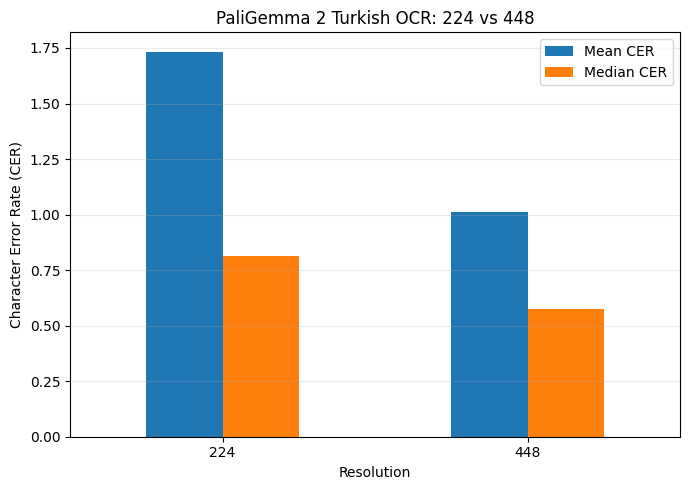

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("results").mkdir(exist_ok=True)

summary_plot = (
    comparison[["cer_224", "cer_448"]]
    .agg(["mean", "median"])
    .T
)

summary_plot.index = ["224", "448"]

ax = summary_plot.plot(
    kind="bar",
    figsize=(7, 5),
    rot=0
)

ax.set_title("PaliGemma 2 Turkish OCR: 224 vs 448")
ax.set_xlabel("Resolution")
ax.set_ylabel("Character Error Rate (CER)")
ax.legend(["Mean CER", "Median CER"])
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("results/cer_summary.png", dpi=300, bbox_inches="tight")
plt.show()

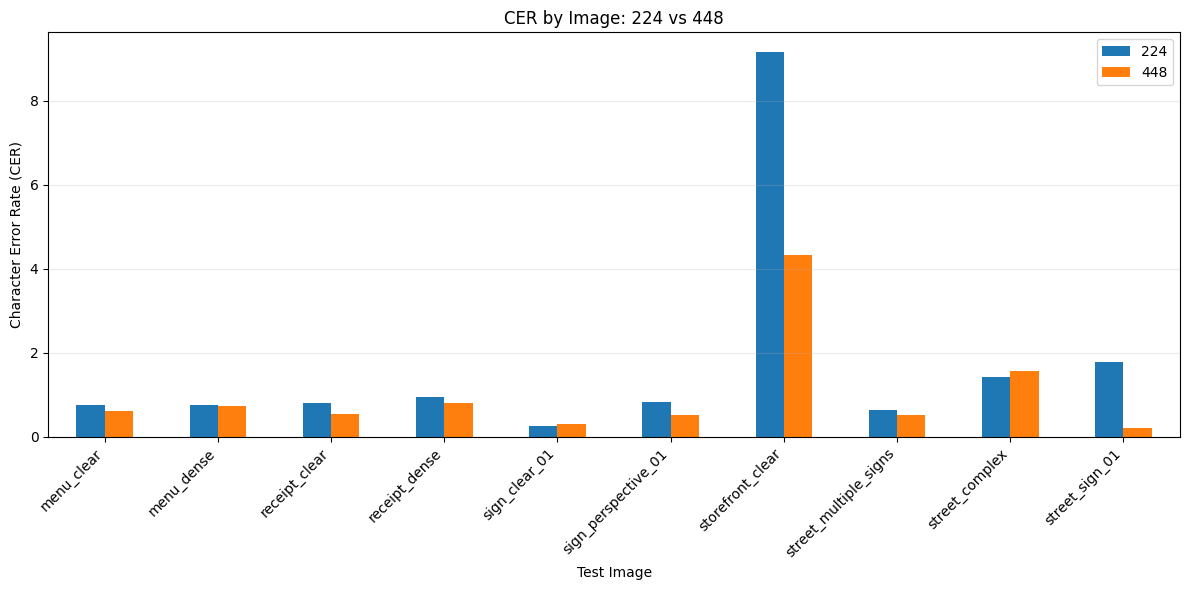

In [21]:
plot_df = comparison.set_index("id")[["cer_224", "cer_448"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("CER by Image: 224 vs 448")
ax.set_xlabel("Test Image")
ax.set_ylabel("Character Error Rate (CER)")
ax.legend(["224", "448"])
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("results/cer_per_image.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Results

With `OCR_PROMPT = "ocr"`, the 448 checkpoint had lower CER on 8/10 images. The 224 checkpoint was better on `sign_clear_01` and `street_multiple_signs`; there were no ties.

Mean CER went from 1.7338 (224) to 1.0104 (448), a reduction of approximately 41.7%. Median CER went from 0.8154 to 0.5730. Several difficult text images improved, with a large difference on `street_sign_01`.

`storefront_clear` was a major outlier: CER was 9.1698 at 224 and 4.3208 at 448. Some predictions showed repetition loops, causing very high insertion errors. CER can therefore exceed 1.0, and these failures strongly affect the mean.


## 14. Limitations

Only 10 manually selected images were used. This is an exploratory experiment, not a benchmark, and the results should not be generalized to Turkish OCR overall.

The 224 and 448 versions are separate released checkpoints, so the difference cannot be attributed purely to resizing the same weights. Repetitive generation affects CER, and the fixed output cap can truncate long predictions. The ground-truth transcriptions may not capture every tiny or ambiguous visible text element.


## 15. Conclusion

The 448px checkpoint performed better overall in this small Turkish OCR experiment, especially on several difficult text images. It still made errors and showed repetition loops, and 224 was better on two images. The sample is too small for broad conclusions, but these results give me a useful starting point for further experiments.


## References

1. Steiner, A., et al. (2024). [*PaliGemma 2: A Family of Versatile VLMs for Transfer*](https://arxiv.org/abs/2412.03555). Google. arXiv:2412.03555.
2. Google. [PaliGemma 2 3B Mix 224 model card](https://huggingface.co/google/paligemma2-3b-mix-224).
3. Google. [PaliGemma 2 3B Mix 448 model card](https://huggingface.co/google/paligemma2-3b-mix-448).
4. Hugging Face. [Transformers PaliGemma documentation](https://huggingface.co/docs/transformers/model_doc/paligemma), with [version 4.57.1 documentation](https://huggingface.co/docs/transformers/v4.57.1/en/model_doc/paligemma) for the pinned runtime.